In [324]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [325]:
BASE_PATH = '../dataset'
EDA_OUTPUT_FOLDER = os.path.join(BASE_PATH, 'eda_outputs')
BPS_FOLDER = os.path.join(EDA_OUTPUT_FOLDER, 'bps_cleaned.csv')
NASA_FOLDER = os.path.join(EDA_OUTPUT_FOLDER, 'nasa_cleaned.csv')

# Standardisasi Nama Wilayah

In [326]:
df_bps = pd.read_csv(BPS_FOLDER)
df_nasa = pd.read_csv(NASA_FOLDER)

In [327]:
df_bps.head()

,kabupaten,luas_panen,produktivitas,produksi,tahun
0,Kab. Simeulue,"6085,45",33.20,20200.91,2018
1,Kab. Aceh Singkil,"967,02",56.16,5430.41,2018
2,Kab. Aceh Selatan,"9242,78",62.29,57573.07,2018
3,Kab. Aceh Tenggara,"10488,65",65.45,68651.03,2018
4,Kab. Aceh Timur,"30947,54",56.40,174531.52,2018


In [328]:
df_bps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2530 entries, 0 to 2529
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   kabupaten      2530 non-null   object 
 1   luas_panen     2530 non-null   object 
 2   produktivitas  2530 non-null   float64
 3   produksi       2530 non-null   float64
 4   tahun          2530 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 99.0+ KB


In [329]:
df_nasa.head(10)

,provinsi,kabupaten,lat,long,date,curah_hujan,temp_2m,kelembapan_2m
0,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-01,2.55,24.54,86.11
1,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-02,7.93,24.86,85.58
2,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-03,37.44,24.47,83.77
3,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-04,5.53,24.55,86.93
4,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-05,0.25,24.65,81.61
5,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-06,0.01,25.20,77.43
6,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-07,1.65,25.37,72.52
7,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-08,2.27,25.01,81.68
8,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-09,0.79,24.69,76.56
9,Aceh,Kab. Aceh Barat Daya,3.6147,97.0697,2018-01-10,0.80,24.90,77.36


In [330]:
df_nasa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501908 entries, 0 to 1501907
Data columns (total 8 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   provinsi       1501908 non-null  object 
 1   kabupaten      1501908 non-null  object 
 2   lat            1501908 non-null  float64
 3   long           1501908 non-null  float64
 4   date           1501908 non-null  object 
 5   curah_hujan    1501908 non-null  float64
 6   temp_2m        1501908 non-null  float64
 7   kelembapan_2m  1501908 non-null  float64
dtypes: float64(5), object(3)
memory usage: 91.7+ MB


In [331]:
df_bps["kabupaten"] = (
    df_bps["kabupaten"]
    .str.lower()
    .str.replace("kab. ", "", regex=False)
    .str.replace("kota ", "", regex=False)
    .str.strip()
)

df_nasa["kabupaten"] = (
    df_nasa["kabupaten"]
    .str.lower()
    .str.replace("kab. ", "", regex=False)
    .str.replace("kota ", "", regex=False)
    .str.strip()
)

In [332]:
set(df_bps["kabupaten"]) - set(df_nasa["kabupaten"])

{'kepulauan sangihe',
 'kepulauan talaud',
 'labuhan batu',
 'pangkajene dan kepulauan',
 'pematang siantar',
 'tanjung balai',
 'toba samosir',
 'tulang bawang barat'}

In [333]:
perbaikan_nama = {
    'batang hari': 'batanghari',
    'embrana': 'jembrana',
    'gunung kidul': 'gunungkidul',
    'karang asem': 'karangasem',
    'kepulauan sangihe': 'kepulauan sangihe',  
    'sangihe': 'kepulauan sangihe',  
    'kepulauan talaud': 'kepulauan talaud',
    'talaud': 'kepulauan talaud',
    'kulon progo': 'kulonprogo',
    'labuhan batu': 'labuhanbatu',
    'pangkajene dan kepulauan': 'pangkajene kepulauan', 
    'pangkal pinang': 'pangkalpinang',
    'pematang siantar': 'pematangsiantar',
    'tanjung balai': 'tanjungbalai',
    'tanjung pinang': 'tanjungpinang',
    'toba samosir': 'toba',                     
    'tulang bawang barat': 'tulang bawang barat',
    'tulangbawang barat': 'tulang bawang barat'
}   

In [334]:
df_bps["kabupaten"] = df_bps["kabupaten"].replace(perbaikan_nama)
df_nasa["kabupaten"] = df_nasa["kabupaten"].replace(perbaikan_nama)

In [335]:
sisa_perbedaan = set(df_bps["kabupaten"]) - set(df_nasa["kabupaten"])
print("Sisa data yang belum sama:", list(sisa_perbedaan))

Sisa data yang belum sama: []


In [336]:
df_nasa["date"] = pd.to_datetime(df_nasa["date"], errors='coerce')
df_nasa["tahun"] = df_nasa["date"].dt.year

In [337]:
nasa_yearly = (
    df_nasa.groupby(["kabupaten", "tahun"])
    .agg(
        curah_hujan_rataan = ("curah_hujan", "mean"),
        curah_hujan_total  = ("curah_hujan", "sum"),
        
        suhu_rataan        = ("temp_2m", "mean"),
        suhu_maksimum      = ("temp_2m", "max"),
        suhu_minimum       = ("temp_2m", "min"),
        
        kelembapan_rataan  = ("kelembapan_2m", "mean")
    )
    .reset_index()
)

# Menampilkan 5 data teratas untuk pengecekan
nasa_yearly.head(5)

,kabupaten,tahun,curah_hujan_rataan,curah_hujan_total,suhu_rataan,suhu_maksimum,suhu_minimum,kelembapan_rataan
0,aceh barat,2018,7.743973,2826.55,26.383507,27.96,24.56,83.776986
1,aceh barat,2019,6.128877,2237.04,26.726247,28.40,24.75,83.668603
2,aceh barat,2020,8.758689,3205.68,26.619290,28.46,24.26,82.904809
3,aceh barat,2021,8.015068,2925.50,26.461781,27.90,24.40,82.470000
4,aceh barat,2022,8.484603,3096.88,26.371699,28.13,24.30,83.293918


In [338]:
nasa_yearly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   kabupaten           3904 non-null   object 
 1   tahun               3904 non-null   int32  
 2   curah_hujan_rataan  3904 non-null   float64
 3   curah_hujan_total   3904 non-null   float64
 4   suhu_rataan         3904 non-null   float64
 5   suhu_maksimum       3904 non-null   float64
 6   suhu_minimum        3904 non-null   float64
 7   kelembapan_rataan   3904 non-null   float64
dtypes: float64(6), int32(1), object(1)
memory usage: 228.9+ KB


In [339]:
df_bps['tahun'] = (df_bps['tahun'])

In [340]:
final_df = pd.merge(
    df_bps,
    nasa_yearly,
    on=[
        "kabupaten",
        "tahun"
    ],
    how="inner"
)

In [341]:
# Pembersihan kolom luas_panen agar menjadi angka desimal (float)
final_df['luas_panen'] = final_df['luas_panen'].astype(str).str.strip()
final_df['luas_panen'] = final_df['luas_panen'].str.replace(' ', '', regex=False)
final_df['luas_panen'] = final_df['luas_panen'].str.replace(',', '.', regex=False)
final_df['luas_panen'] = pd.to_numeric(final_df['luas_panen'], errors='coerce')

In [342]:
final_df.shape

(2530, 11)

In [343]:
final_df.head()

,kabupaten,luas_panen,produktivitas,produksi,tahun,curah_hujan_rataan,curah_hujan_total,suhu_rataan,suhu_maksimum,suhu_minimum,kelembapan_rataan
0,simeulue,6085.45,33.20,20200.91,2018,6.432411,2347.83,27.843425,29.21,26.08,78.489041
1,aceh singkil,967.02,56.16,5430.41,2018,8.170110,2982.09,27.493616,29.15,25.60,79.534411
2,aceh selatan,9242.78,62.29,57573.07,2018,6.786082,2476.92,25.206000,26.80,23.05,85.036521
3,aceh tenggara,10488.65,65.45,68651.03,2018,6.761041,2467.78,20.623315,22.63,18.18,88.931945
4,aceh timur,30947.54,56.40,174531.52,2018,4.523507,1651.08,27.475507,29.50,25.26,79.901616


In [344]:
final_df.to_csv(
    os.path.join(EDA_OUTPUT_FOLDER, 'final_merged_data.csv'),
    index=False
)

In [345]:
value_kosong = final_df[final_df.isnull().any(axis=1)]
value_kosong

,kabupaten,luas_panen,produktivitas,produksi,tahun,curah_hujan_rataan,curah_hujan_total,suhu_rataan,suhu_maksimum,suhu_minimum,kelembapan_rataan
1533,bontang,NaN,29.39,1.0,2025,7.742082,2825.86,27.081808,28.63,25.3,84.941068


In [346]:
final_df = final_df.dropna(subset=['luas_panen'])

In [347]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2529 entries, 0 to 2529
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   kabupaten           2529 non-null   object 
 1   luas_panen          2529 non-null   float64
 2   produktivitas       2529 non-null   float64
 3   produksi            2529 non-null   float64
 4   tahun               2529 non-null   int64  
 5   curah_hujan_rataan  2529 non-null   float64
 6   curah_hujan_total   2529 non-null   float64
 7   suhu_rataan         2529 non-null   float64
 8   suhu_maksimum       2529 non-null   float64
 9   suhu_minimum        2529 non-null   float64
 10  kelembapan_rataan   2529 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 237.1+ KB


In [353]:
final_df.to_csv(os.path.join(BASE_PATH, 'dataset_produksi_padi.csv'), index=False)

In [349]:
final_df.columns = final_df.columns.str.strip()
corr_matrix = final_df.select_dtypes(include=np.number).corr()

In [350]:
corr_matrix.head()

,luas_panen,produktivitas,produksi,tahun,curah_hujan_rataan,curah_hujan_total,suhu_rataan,suhu_maksimum,suhu_minimum,kelembapan_rataan
luas_panen,1.000000,0.340136,0.988590,-0.008827,-0.141469,-0.081755,0.071077,0.147488,0.005233,-0.168969
produktivitas,0.340136,1.000000,0.400093,0.031709,-0.249341,0.016412,-0.233456,-0.082108,-0.315180,-0.234340
produksi,0.988590,0.400093,1.000000,-0.000849,-0.153739,-0.086025,0.057527,0.140868,-0.012446,-0.183465
tahun,-0.008827,0.031709,-0.000849,1.000000,0.168864,0.128840,0.061068,0.020459,0.086076,0.145332
curah_hujan_rataan,-0.141469,-0.249341,-0.153739,0.168864,1.000000,0.663464,-0.337941,-0.475669,-0.244742,0.657418


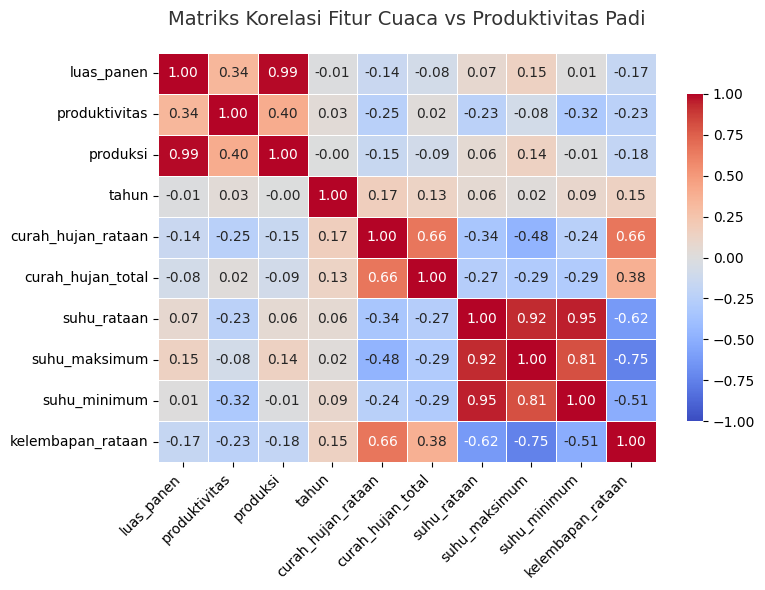

In [351]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    mask=None,                  
    annot=True,                 
    fmt=".2f",                  
    cmap="coolwarm",            
    vmax=1, vmin=-1,            
    center=0,                   
    linewidths=0.5,             
    cbar_kws={"shrink": 0.8}    
)

plt.title(
    "Matriks Korelasi Fitur Cuaca vs Produktivitas Padi", 
    fontsize=14, 
    pad=20, 
    color='#333333'
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(
    os.path.join(EDA_OUTPUT_FOLDER, 'matriks_korelasi_final.png'), 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()